In [22]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import scipy
import scipy.ndimage
import torch
from tqdm import tqdm

from grid_pattern_formation.evals.core import build_eval_context, get_cached_ratemaps
from grid_pattern_formation.evals.analysis_connectivity import _compute_phase_order, _compute_jmean, _compute_phase_original_order
from grid_pattern_formation.evals.analysis_dynamics import get_fourier_spectrum, find_peak_coordinates
from grid_pattern_formation.evals.analysis_core import compute_grid_scores
from grid_pattern_formation.utils.two_d_sort import get_2d_sort

%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

In [47]:
baseline_ctx = build_eval_context(
    checkpoint_path="../checkpoints/replicate_baseline_colab_orig_rmsprop_alive.pth",
    config_path="../configs/replicate_baseline_colab_orig_rmsprop_alive.yaml",
    results_root="../results/phase_analysis",
)
topo_ctx = build_eval_context(
    checkpoint_path="../checkpoints/cos_decay_hw4_final_model.pth",
    config_path="../configs/topo_cos_decay_hw4.yaml",
    results_root="../results/phase_analysis",
)

RES = 50
N_AVG = 100
Ng = 4096
n = int(np.sqrt(Ng))

print("Baseline ratemaps")
baseline_act, baseline_rm, baseline_g, baseline_pos = get_cached_ratemaps(baseline_ctx, res=RES, n_avg=N_AVG, ng=Ng)
print("Topoloss ratemaps")
topo_act, topo_rm, topo_g, topo_pos = get_cached_ratemaps(topo_ctx, res=RES, n_avg=N_AVG, ng=Ng)

# Sorted baseline
baseline_order, baseline_phases = _compute_phase_order(baseline_ctx, baseline_rm, RES)
# Unsorted topoloss
topo_order, topo_phases = _compute_phase_original_order(topo_ctx, topo_rm, RES)

J_baseline = baseline_ctx.model.RNN.weight_hh_l0.detach().cpu().numpy().T
J_topo = topo_ctx.model.RNN.weight_hh_l0.detach().cpu().numpy().T

# Unsorted baseline
baseline_order_unsorted, baseline_phases_unsorted = _compute_phase_original_order(baseline_ctx, baseline_rm, RES)

# Sorted baseline phases
baseline_phases_sorted = baseline_phases[:, baseline_order]

J_baseline_sorted = J_baseline[baseline_order][:, baseline_order]

# Sorted baseline activations & scores
baseline_act_sorted = baseline_act[baseline_order]

print("Baseline grid scores")
baseline_scores = compute_grid_scores(baseline_ctx)
print("Topoloss grid scores")
topo_scores = compute_grid_scores(topo_ctx)

baseline_score60 = baseline_scores["score_60"]
topo_score60 = topo_scores["score_60"]
baseline_score60_sorted = baseline_score60[baseline_order]

Baseline ratemaps
Topoloss ratemaps
Baseline grid scores


Grid scores: 100%|██████████| 4096/4096 [00:13<00:00, 310.10it/s]


Topoloss grid scores


Grid scores: 100%|██████████| 4096/4096 [00:12<00:00, 324.65it/s]


In [48]:
def circular_diff(a, b):
    d = a - b
    return (d + np.pi) % (2 * np.pi) - np.pi

def phase_gradient_magnitude(phases_1d, side):
    sheet = phases_1d.reshape(side, side)
    dx = np.zeros_like(sheet)
    dy = np.zeros_like(sheet)
    dx[:, 1:] = circular_diff(sheet[:, 1:], sheet[:, :-1])
    dy[1:, :] = circular_diff(sheet[1:, :], sheet[:-1, :])
    return np.sqrt(dx**2 + dy**2)

def phase_autocorrelation(phases_1d, side, max_lag=20):
    sheet = phases_1d.reshape(side, side)
    autocorr = np.zeros(max_lag)
    for lag in range(1, max_lag + 1):
        if lag >= side:
            autocorr[lag - 1] = np.nan
            continue
        cos_diff_x = np.cos(circular_diff(sheet[:, lag:], sheet[:, :-lag])).mean()
        cos_diff_y = np.cos(circular_diff(sheet[lag:, :], sheet[:-lag, :])).mean()
        autocorr[lag - 1] = (cos_diff_x + cos_diff_y) / 2
    return autocorr

def radial_profile(jmean, max_r=None):
    center = np.array(jmean.shape) // 2
    Y, X = np.ogrid[:jmean.shape[0], :jmean.shape[1]]
    r = np.sqrt((X - center[1])**2 + (Y - center[0])**2).astype(int)
    if max_r is None:
        max_r = min(center)
    radial = np.zeros(max_r)
    for ri in range(max_r):
        mask = r == ri
        if mask.sum() > 0:
            radial[ri] = jmean[mask].mean()
    return radial

A_hex = np.asarray([[2, 1], [0, np.sqrt(3)]]) / 2
A_hex_inv = np.linalg.inv(A_hex)

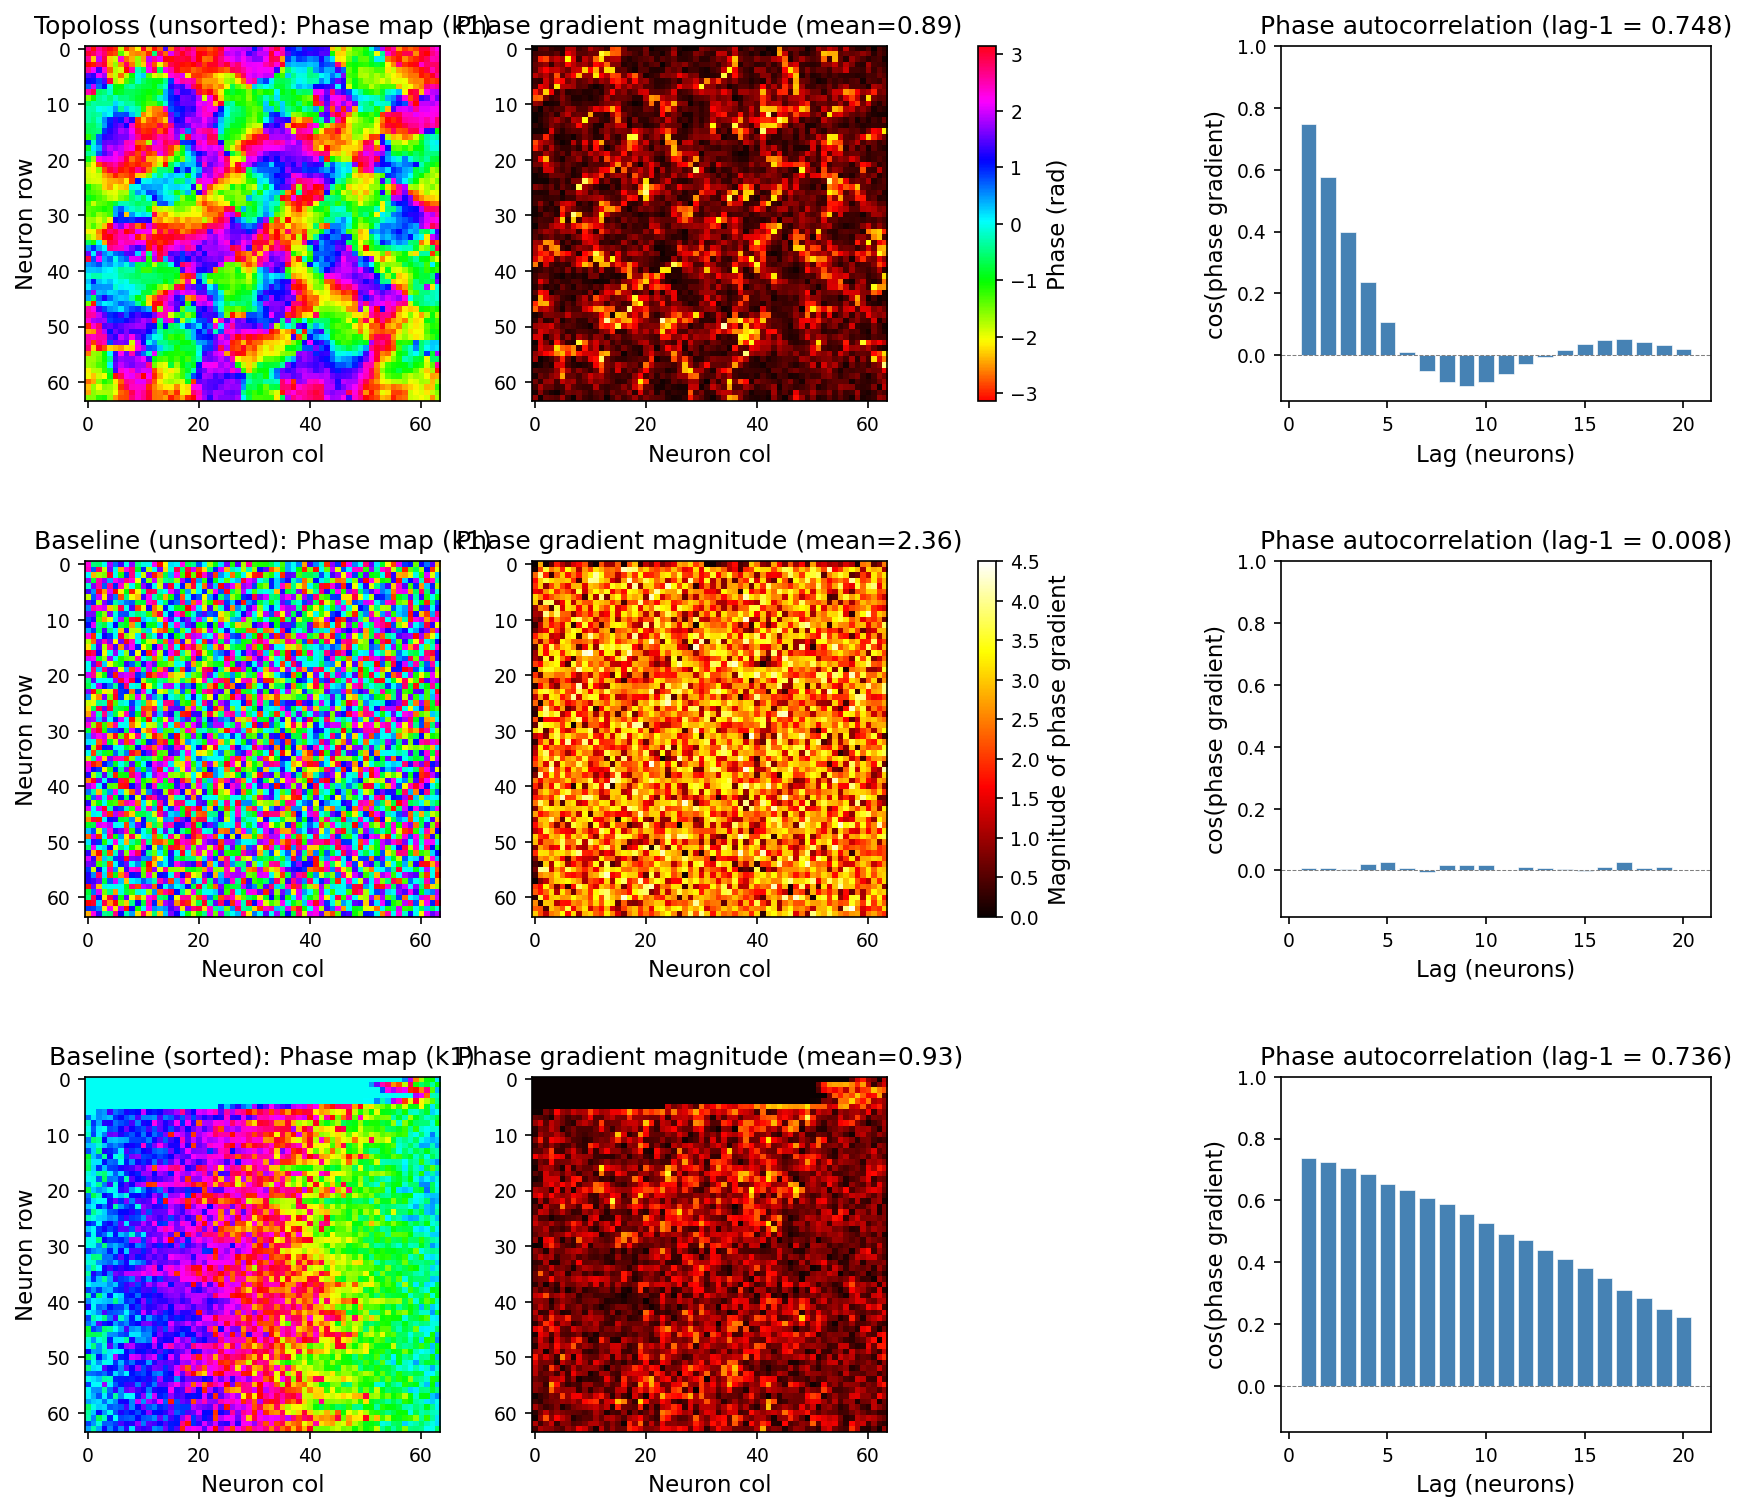

In [49]:
fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(3, 5, width_ratios=[1, 1, 0.05, 0.3, 1.2], wspace=0.35, hspace=0.45)

mode_idx = 0 # k1

for row, (label, phases) in enumerate([
    ("Topoloss (unsorted)", topo_phases),
    ("Baseline (unsorted)", baseline_phases_unsorted),
    ("Baseline (sorted)", baseline_phases_sorted),
]):
    phase_sheet = phases[mode_idx].reshape(n, n)
    grad_mag = phase_gradient_magnitude(phases[mode_idx], n)
    autocorr = phase_autocorrelation(phases[mode_idx], n, max_lag=20)

    # Phase map
    ax0 = fig.add_subplot(gs[row, 0])
    im0 = ax0.imshow(phase_sheet, cmap="hsv", vmin=-np.pi, vmax=np.pi)
    ax0.set_title(f"{label}: Phase map (k1)")
    ax0.set_ylabel("Neuron row")
    ax0.set_xlabel("Neuron col")

    # Gradient magnitude
    ax1 = fig.add_subplot(gs[row, 1])
    im1 = ax1.imshow(grad_mag, cmap="hot", vmin=0, vmax=4.5)
    ax1.set_title(f"Phase gradient magnitude (mean={grad_mag.mean():.2f})")
    ax1.set_xlabel("Neuron col")

    # Autocorrelation
    ax2 = fig.add_subplot(gs[row, 4])
    ax2.bar(range(1, 21), autocorr, color="steelblue", edgecolor="white", linewidth=0.3)
    ax2.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax2.set_xlabel("Lag (neurons)")
    ax2.set_ylabel("cos(phase gradient)")
    ax2.set_title(f"Phase autocorrelation (lag-1 = {autocorr[0]:.3f})")
    ax2.set_ylim([-0.15, 1.0])

# Colorbars
cax0 = fig.add_subplot(gs[0, 2])
plt.colorbar(im0, cax=cax0, label="Phase (rad)")
cax1 = fig.add_subplot(gs[1, 2])
plt.colorbar(im1, cax=cax1, label="Magnitude of phase gradient")

plt.show()

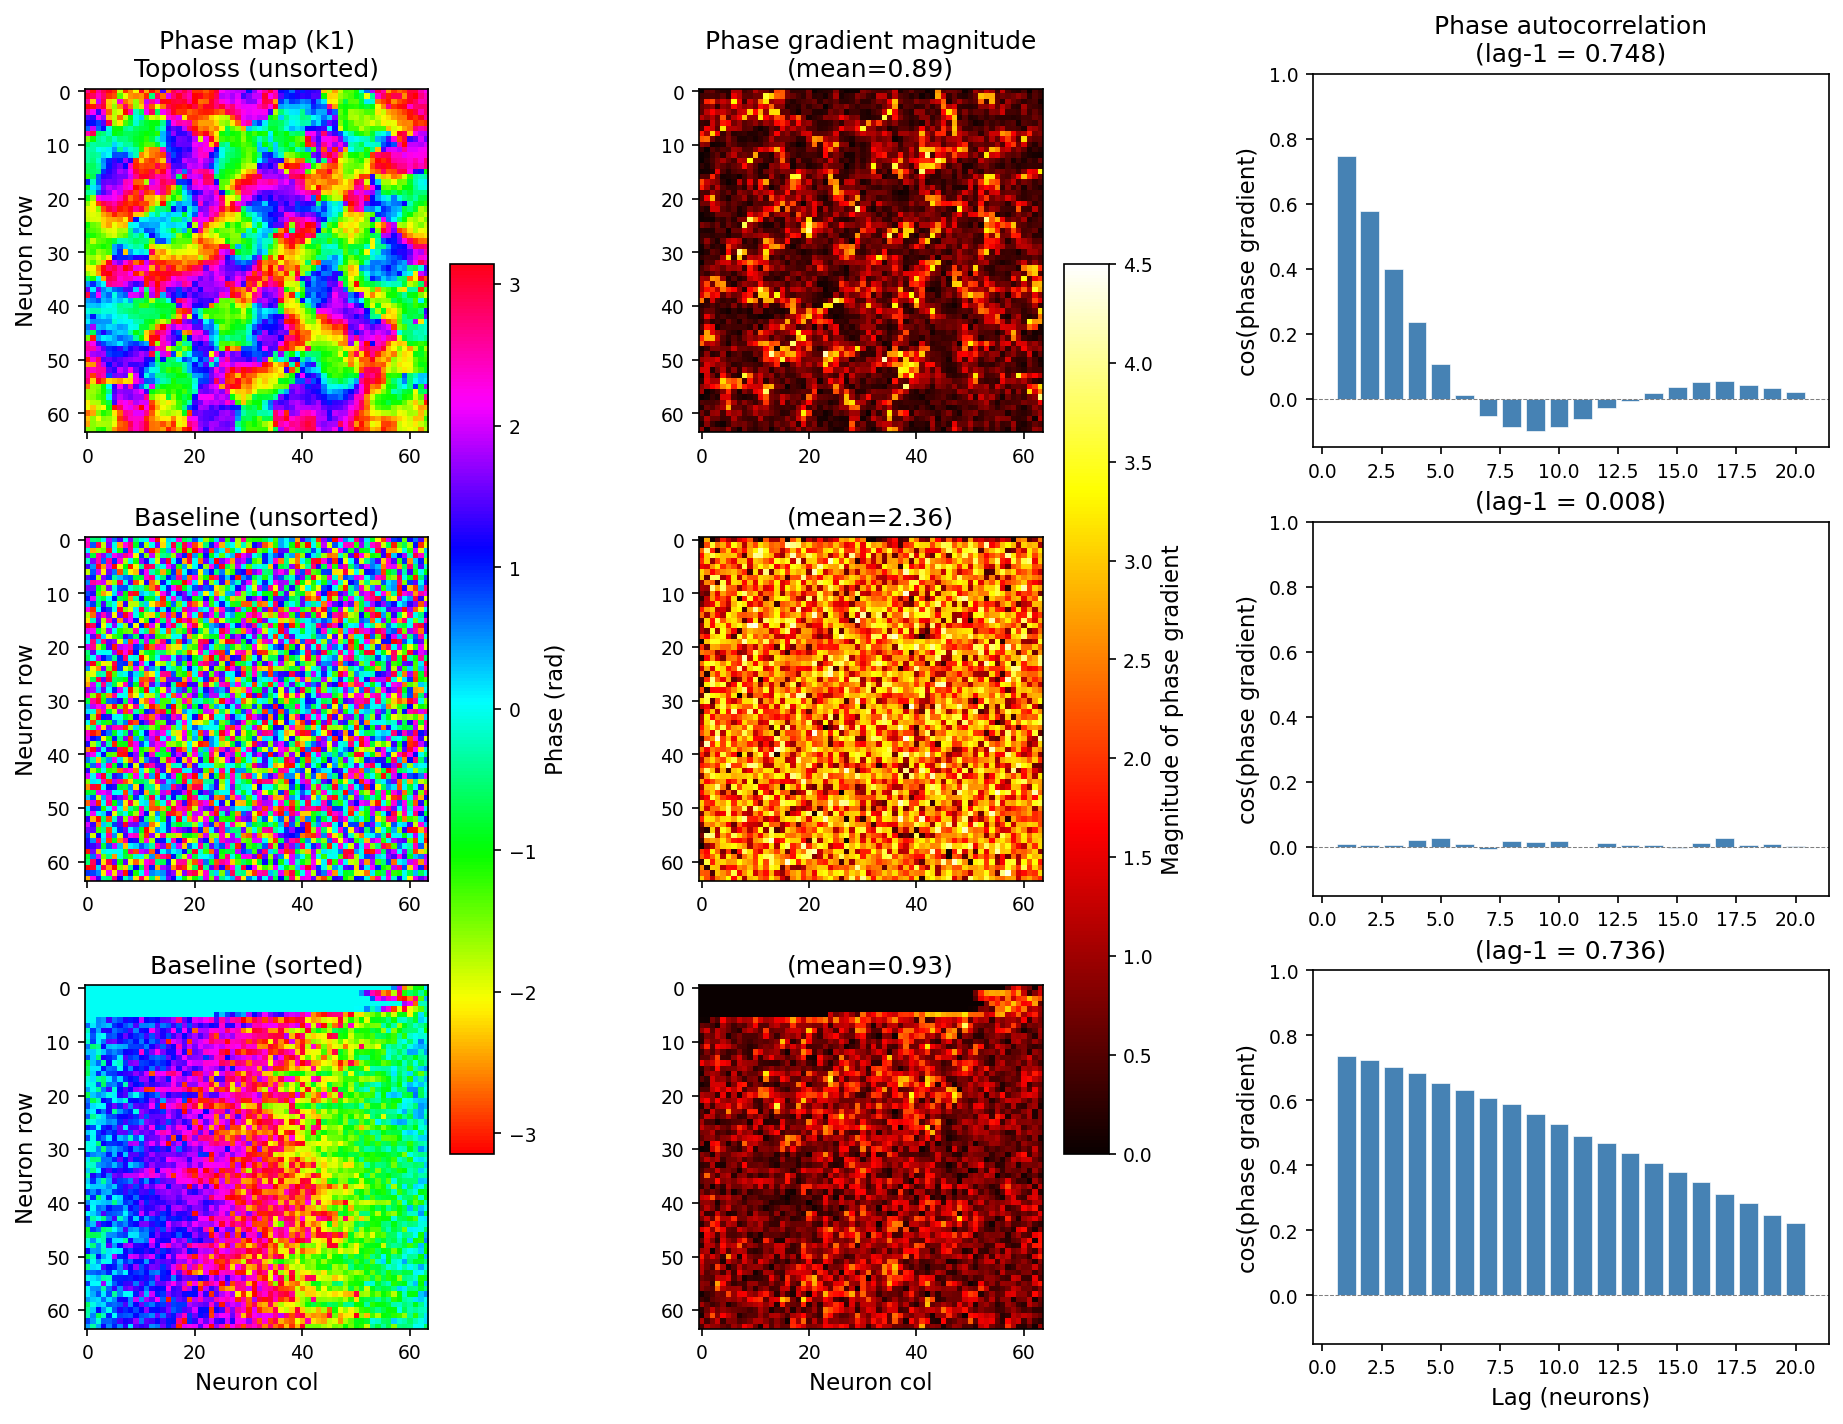

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 11), constrained_layout=True)

gs = gridspec.GridSpec(3, 5, width_ratios=[1, 0.15, 1, 0.15, 1.2])

mode_idx = 0 # k1

phase_axes = []
grad_axes = []

for row, (label, phases) in enumerate([
    ("Topoloss (unsorted)", topo_phases),
    ("Baseline (unsorted)", baseline_phases_unsorted),
    ("Baseline (sorted)", baseline_phases_sorted),
]):
    phase_sheet = phases[mode_idx].reshape(n, n)
    grad_mag = phase_gradient_magnitude(phases[mode_idx], n)
    autocorr = phase_autocorrelation(phases[mode_idx], n, max_lag=20)

    ax0 = fig.add_subplot(gs[row, 0])
    im0 = ax0.imshow(phase_sheet, cmap="hsv", vmin=-np.pi, vmax=np.pi)
    ax0.set_ylabel("Neuron row")
    if row == 2:
        ax0.set_xlabel("Neuron col")
    phase_axes.append(ax0)

    ax1 = fig.add_subplot(gs[row, 2])
    im1 = ax1.imshow(grad_mag, cmap="hot", vmin=0, vmax=4.5)
    if row == 2:
        ax1.set_xlabel("Neuron col")
    grad_axes.append(ax1)

    ax2 = fig.add_subplot(gs[row, 4])
    ax2.bar(range(1, 21), autocorr, color="steelblue", edgecolor="white", linewidth=0.3)
    ax2.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax2.set_ylabel("cos(phase gradient)")
    ax2.set_ylim([-0.15, 1.0])
    if row == 2:
        ax2.set_xlabel("Lag (neurons)")

    if row == 0:
        ax0.set_title(f"Phase map (k1)\n{label}")
        ax1.set_title(f"Phase gradient magnitude\n(mean={grad_mag.mean():.2f})")
        ax2.set_title(f"Phase autocorrelation\n(lag-1 = {autocorr[0]:.3f})")
    else:
        ax0.set_title(label)
        ax1.set_title(f"(mean={grad_mag.mean():.2f})")
        ax2.set_title(f"(lag-1 = {autocorr[0]:.3f})")

# Colorbars
fig.colorbar(im0, ax=phase_axes, shrink=0.7, label="Phase (rad)")
fig.colorbar(im1, ax=grad_axes, shrink=0.7, label="Magnitude of phase gradient")

plt.show()

In [51]:
from scipy.ndimage import minimum_filter

def find_grid_patches(scores, n, n_patches=3, patch_size=5, min_gap=6):
    score_sheet = scores.reshape(n, n)
    min_score_map = minimum_filter(score_sheet, size=patch_size, mode="constant", cval=-np.inf)
    half = patch_size // 2
    valid_mask = np.zeros_like(score_sheet, dtype=bool)
    valid_mask[half:n-half, half:n-half] = True
    patch_scores = np.where(valid_mask, min_score_map, -np.inf).ravel()
    best_patch_idx = np.argsort(patch_scores)[::-1]
    
    patch_centers = []
    for idx in best_patch_idx:
        cy, cx = np.unravel_index(idx, (n, n))
        overlap = False
        for py, px in patch_centers:
            dy = abs(cy - py)
            dx = abs(cx - px)
            if dy < min_gap and dx < min_gap:
                overlap = True
                break
        if not overlap:
            patch_centers.append((cy, cx))
            if len(patch_centers) >= n_patches:
                break
    return patch_centers

# Topoloss patches on unsorted sheet
topo_patches = find_grid_patches(topo_score60, n)

# Baseline patches on unsorted sheet
baseline_patches_unsorted = find_grid_patches(baseline_score60, n)

# Baseline patches on sorted sheet
baseline_patches_sorted = find_grid_patches(baseline_score60_sorted, n)

print("Topoloss patches (unsorted sheet):")
for i, (cy, cx) in enumerate(topo_patches):
    score_sheet = topo_score60.reshape(n, n)
    min_score_map = minimum_filter(score_sheet, size=5, mode="constant", cval=-np.inf)
    print(f"  Patch {i+1}: center=({cy},{cx}), min score = {min_score_map[cy, cx]:.3f}")

print("\nBaseline patches (unsorted sheet):")
for i, (cy, cx) in enumerate(baseline_patches_unsorted):
    score_sheet = baseline_score60.reshape(n, n)
    min_score_map = minimum_filter(score_sheet, size=5, mode="constant", cval=-np.inf)
    print(f"  Patch {i+1}: center=({cy},{cx}), min score = {min_score_map[cy, cx]:.3f}")

print("\nBaseline patches (sorted sheet):")
for i, (cy, cx) in enumerate(baseline_patches_sorted):
    score_sheet = baseline_score60_sorted.reshape(n, n)
    min_score_map = minimum_filter(score_sheet, size=5, mode="constant", cval=-np.inf)
    print(f"  Patch {i+1}: center=({cy},{cx}), min score = {min_score_map[cy, cx]:.3f}")

Topoloss patches (unsorted sheet):
  Patch 1: center=(13,24), min score = 0.763
  Patch 2: center=(18,9), min score = 0.738
  Patch 3: center=(53,15), min score = 0.716

Baseline patches (unsorted sheet):
  Patch 1: center=(26,59), min score = 0.212
  Patch 2: center=(22,28), min score = 0.015
  Patch 3: center=(42,8), min score = 0.015

Baseline patches (sorted sheet):
  Patch 1: center=(60,56), min score = 0.187
  Patch 2: center=(19,14), min score = 0.102
  Patch 3: center=(50,15), min score = 0.089


Text(0.5, 0.95, 'Phase Shifts')

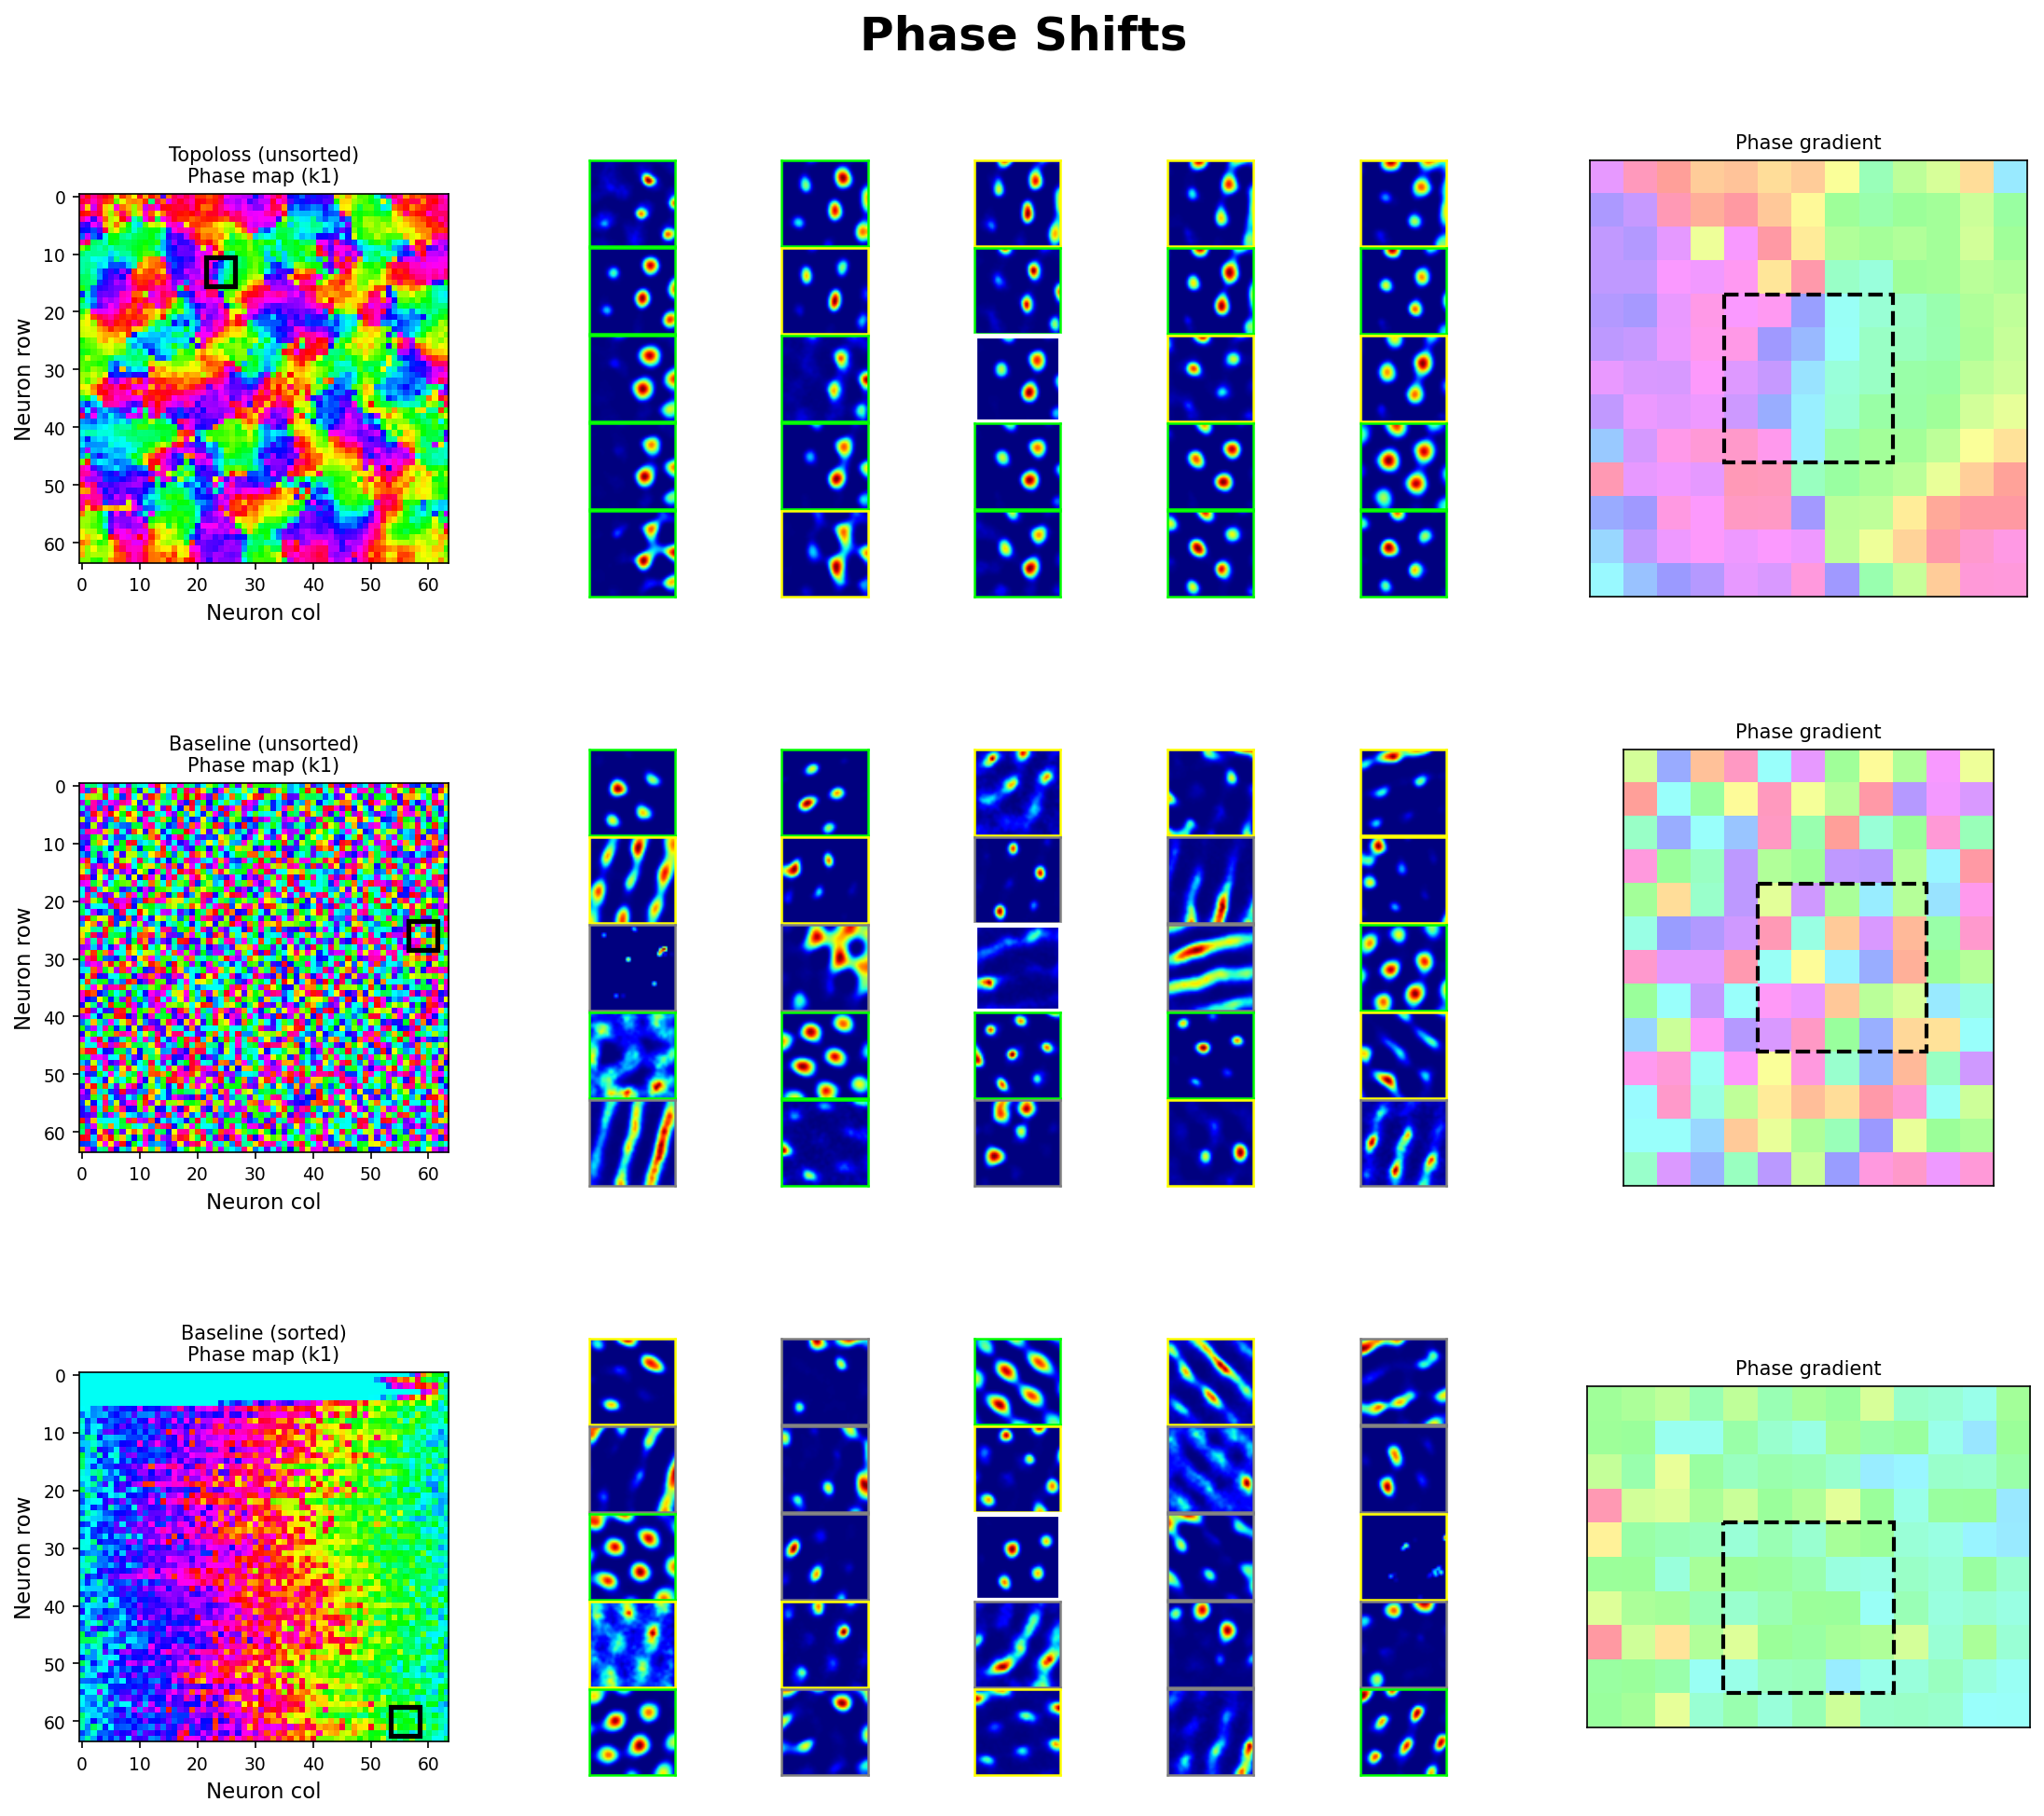

In [52]:
import cv2

patch_size = 5

fig = plt.figure(figsize=(18, 15))
outer_gs = gridspec.GridSpec(3, 3, width_ratios=[0.5, 1.3, 0.6], wspace=0.15, hspace=0.35)

for row, (model_label, patches, scores, act, phases, color) in enumerate([
    ("Topoloss (unsorted)", topo_patches, topo_score60, topo_act, topo_phases, "C1"),
    ("Baseline (unsorted)", baseline_patches_unsorted, baseline_score60, baseline_act, baseline_phases_unsorted, "C0"),
    ("Baseline (sorted)", baseline_patches_sorted, baseline_score60_sorted, baseline_act_sorted, baseline_phases_sorted, "C2"),
]):
    cy, cx = patches[0]
    score_sheet = scores.reshape(n, n)
    
    ax_phase = fig.add_subplot(outer_gs[row, 0])
    phase_sheet = phases[0].reshape(n, n)
    ax_phase.imshow(phase_sheet, cmap="hsv", vmin=-np.pi, vmax=np.pi)
    
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (cx - patch_size // 2 - 0.5, cy - patch_size // 2 - 0.5),
        patch_size, patch_size,
        linewidth=2.5, edgecolor="black", facecolor="none"
    )
    ax_phase.add_patch(rect)
    ax_phase.set_title(f"{model_label}\nPhase map (k1)", fontsize=10)
    ax_phase.set_xlabel("Neuron col")
    ax_phase.set_ylabel("Neuron row")
    
    rate_gs = gridspec.GridSpecFromSubplotSpec(
        patch_size, patch_size, subplot_spec=outer_gs[row, 1],
        wspace=0.02, hspace=0.02
    )
    for di in range(patch_size):
        for dj in range(patch_size):
            row_idx = cy - patch_size // 2 + di
            col_idx = cx - patch_size // 2 + dj
            neuron_idx = row_idx * n + col_idx
            ax_rm = fig.add_subplot(rate_gs[di, dj])
            rm = act[neuron_idx]
            rm_smooth = cv2.GaussianBlur(rm, (3, 3), sigmaX=1, sigmaY=1)
            ax_rm.imshow(rm_smooth, cmap="jet", interpolation="bilinear")
            ax_rm.set_xticks([])
            ax_rm.set_yticks([])
            gs60 = scores[neuron_idx]
            border_color = "lime" if gs60 > 1.0 else ("yellow" if gs60 > 0.5 else "gray")
            for spine in ax_rm.spines.values():
                spine.set_color(border_color)
                spine.set_linewidth(1.2)
            if di == patch_size // 2 and dj == patch_size // 2:
                for spine in ax_rm.spines.values():
                    spine.set_color("white")
                    spine.set_linewidth(2.5)
    
    ax_q = fig.add_subplot(outer_gs[row, 2])
    phase_sheet_nowrap = phases[0].reshape(n, n)
    
    margin = 4
    r_start = max(0, cy - patch_size // 2 - margin)
    c_start = max(0, cx - patch_size // 2 - margin)
    r_end = min(n, cy + patch_size // 2 + margin + 1)
    c_end = min(n, cx + patch_size // 2 + margin + 1)
    
    phase_region = phase_sheet_nowrap[r_start:r_end, c_start:c_end]
    
    ax_q.imshow(phase_region, cmap="hsv", vmin=-np.pi, vmax=np.pi, alpha=0.4)
    
    rect_row = cy - patch_size // 2 - r_start
    rect_col = cx - patch_size // 2 - c_start
    rect2 = Rectangle((rect_col - 0.5, rect_row - 0.5), patch_size, patch_size,
                       linewidth=2, edgecolor="black", facecolor="none", linestyle="--")
    ax_q.add_patch(rect2)
    ax_q.set_title("Phase gradient", fontsize=10)
    ax_q.set_xticks([])
    ax_q.set_yticks([])

fig.suptitle(
    "Phase Shifts",
    fontsize=24, fontweight="bold", y=0.95,
)

Text(0.5, 0.95, 'Phase Shifts')

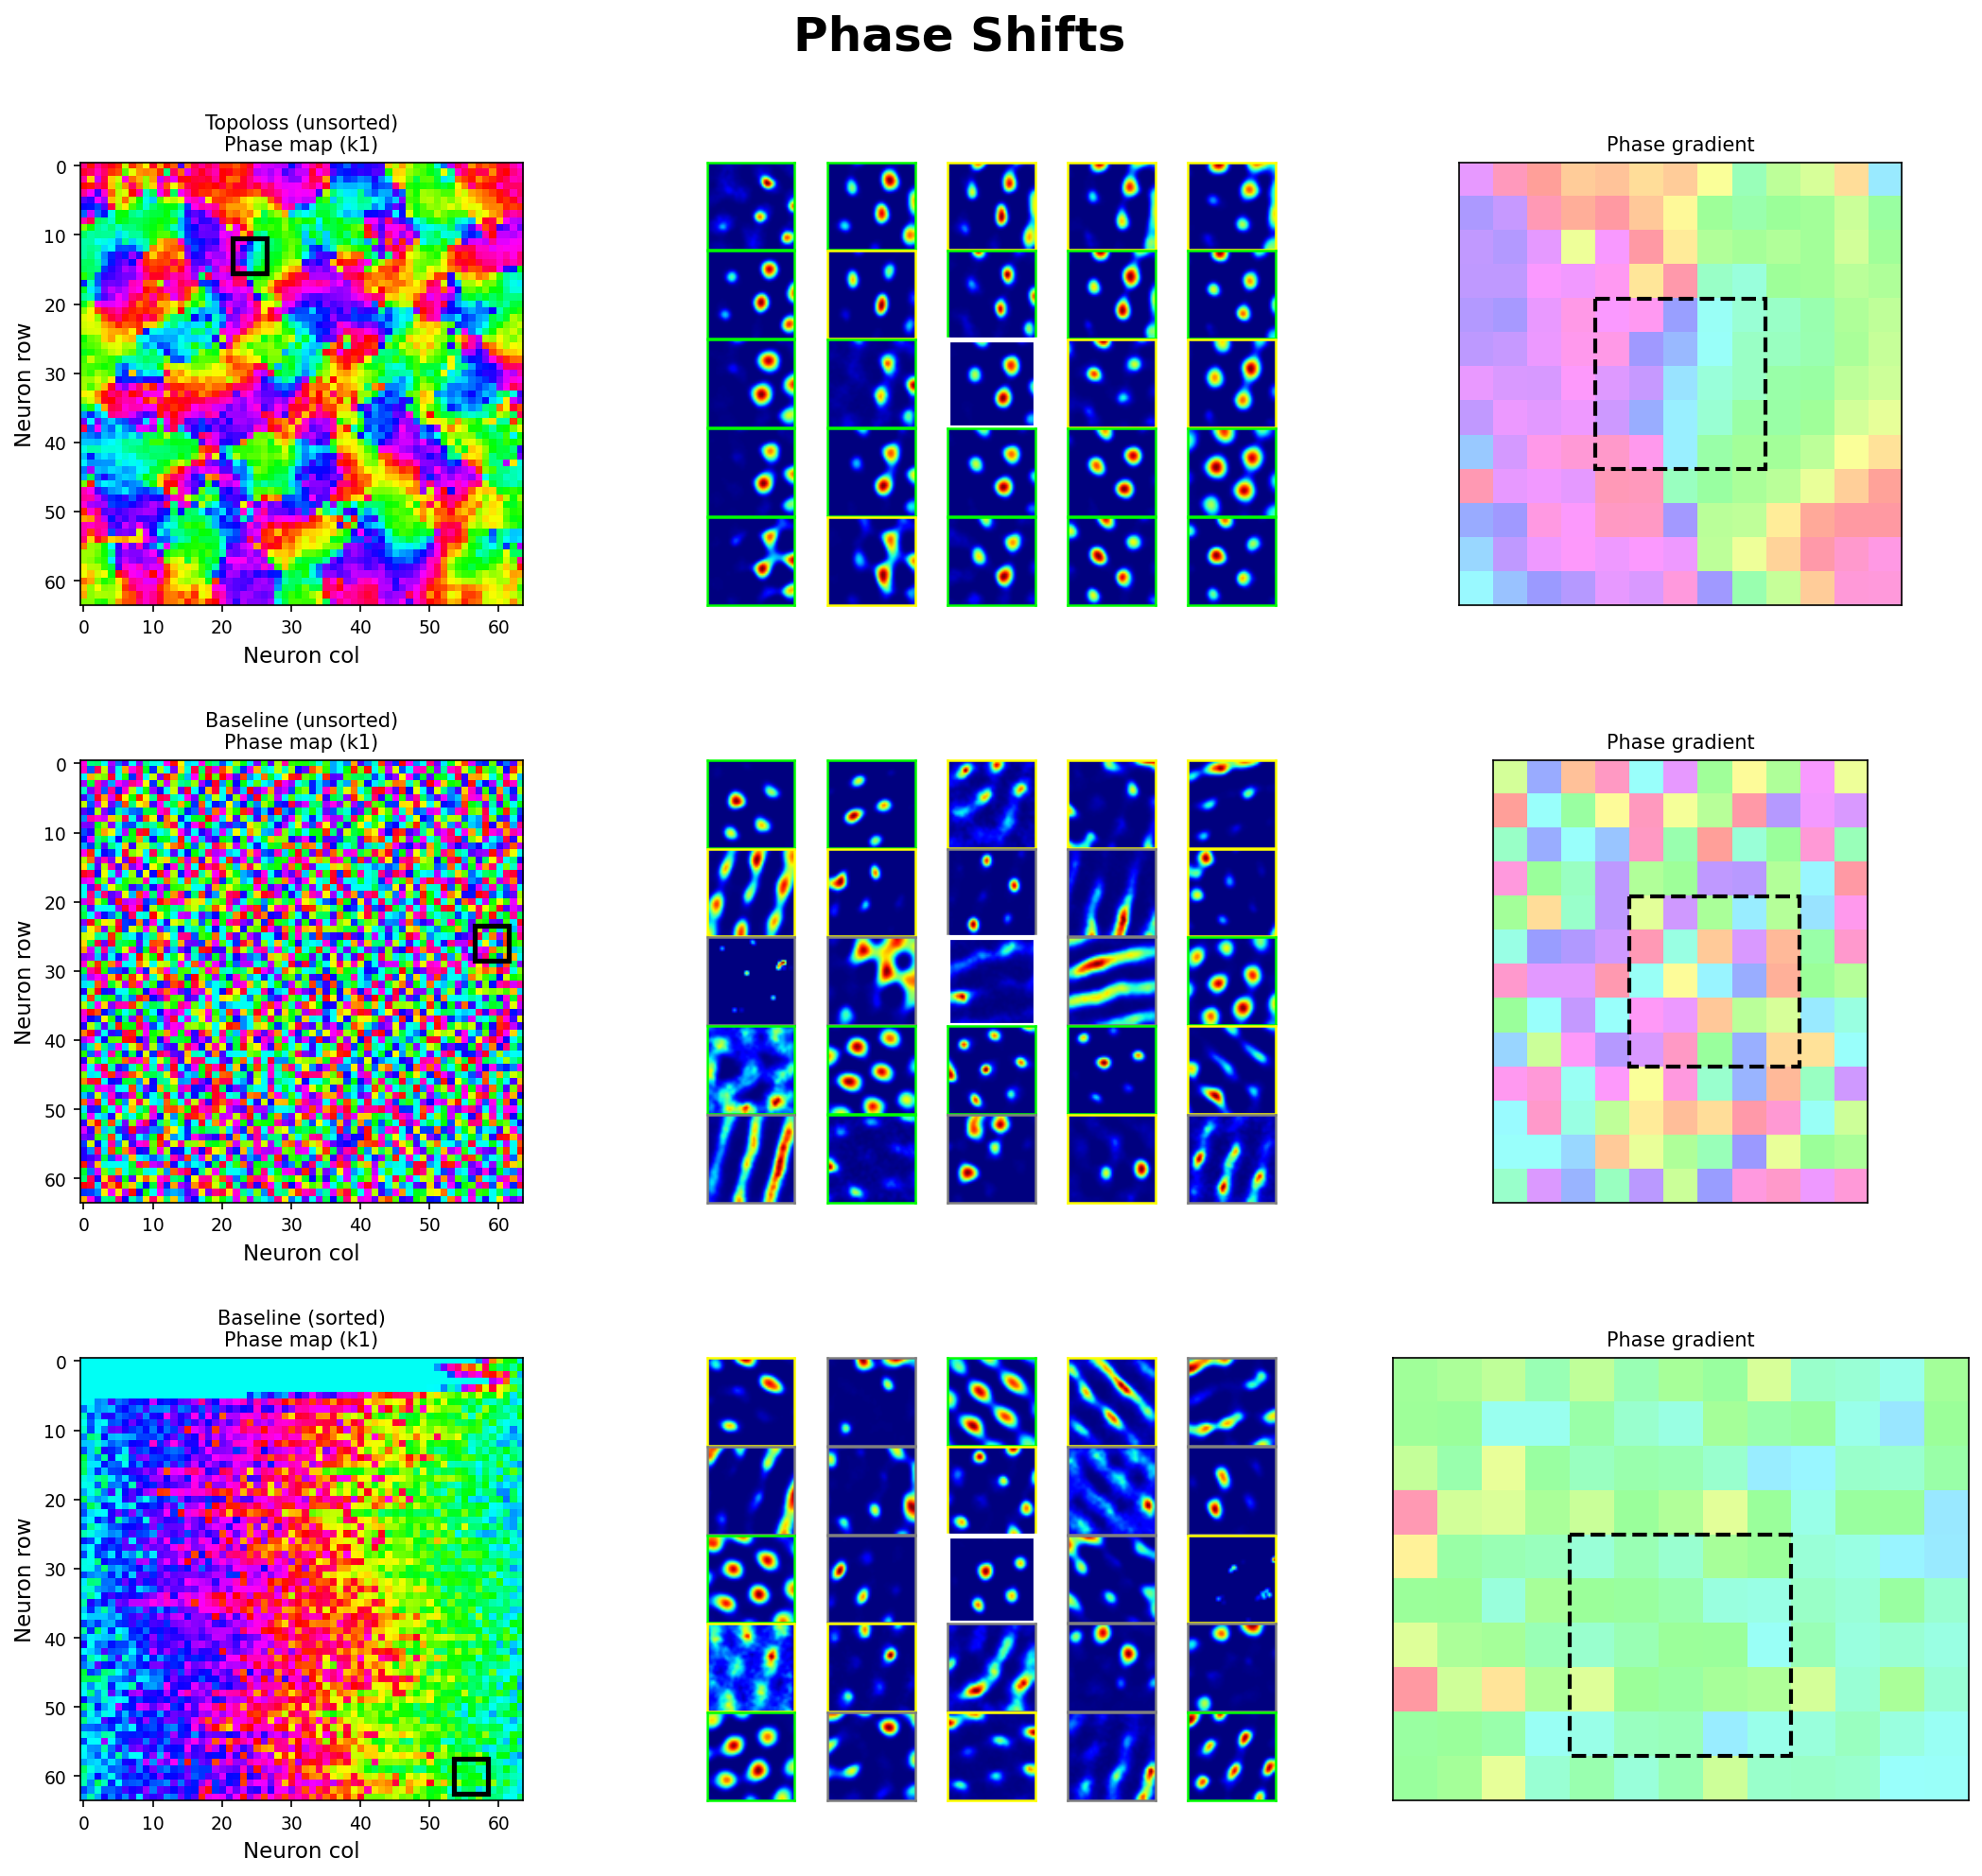

In [53]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

patch_size = 5

fig = plt.figure(figsize=(18, 15))

outer_gs = gridspec.GridSpec(3, 3, width_ratios=[1, 1, 1], wspace=0.15, hspace=0.35)

for row, (model_label, patches, scores, act, phases, color) in enumerate([
    ("Topoloss (unsorted)", topo_patches, topo_score60, topo_act, topo_phases, "C1"),
    ("Baseline (unsorted)", baseline_patches_unsorted, baseline_score60, baseline_act, baseline_phases_unsorted, "C0"),
    ("Baseline (sorted)", baseline_patches_sorted, baseline_score60_sorted, baseline_act_sorted, baseline_phases_sorted, "C2"),
]):
    cy, cx = patches[0]
    score_sheet = scores.reshape(n, n)
    
    ax_phase = fig.add_subplot(outer_gs[row, 0])
    phase_sheet = phases[0].reshape(n, n)
    ax_phase.imshow(phase_sheet, cmap="hsv", vmin=-np.pi, vmax=np.pi)
    
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (cx - patch_size // 2 - 0.5, cy - patch_size // 2 - 0.5),
        patch_size, patch_size,
        linewidth=2.5, edgecolor="black", facecolor="none"
    )
    ax_phase.add_patch(rect)
    ax_phase.set_title(f"{model_label}\nPhase map (k1)", fontsize=10)
    ax_phase.set_xlabel("Neuron col")
    ax_phase.set_ylabel("Neuron row")
    
    rate_gs = gridspec.GridSpecFromSubplotSpec(
        patch_size, patch_size, subplot_spec=outer_gs[row, 1],
        wspace=0.01, hspace=0.01
    )
    for di in range(patch_size):
        for dj in range(patch_size):
            row_idx = cy - patch_size // 2 + di
            col_idx = cx - patch_size // 2 + dj
            neuron_idx = row_idx * n + col_idx
            ax_rm = fig.add_subplot(rate_gs[di, dj])
            rm = act[neuron_idx]
            rm_smooth = cv2.GaussianBlur(rm, (3, 3), sigmaX=1, sigmaY=1)
            ax_rm.imshow(rm_smooth, cmap="jet", interpolation="bilinear")
            ax_rm.set_xticks([])
            ax_rm.set_yticks([])
            gs60 = scores[neuron_idx]
            border_color = "lime" if gs60 > 1.0 else ("yellow" if gs60 > 0.5 else "gray")
            for spine in ax_rm.spines.values():
                spine.set_color(border_color)
                spine.set_linewidth(1.2)
            if di == patch_size // 2 and dj == patch_size // 2:
                for spine in ax_rm.spines.values():
                    spine.set_color("white")
                    spine.set_linewidth(2.5)
    
    ax_q = fig.add_subplot(outer_gs[row, 2])
    phase_sheet_nowrap = phases[0].reshape(n, n)
    
    margin = 4
    r_start = max(0, cy - patch_size // 2 - margin)
    c_start = max(0, cx - patch_size // 2 - margin)
    r_end = min(n, cy + patch_size // 2 + margin + 1)
    c_end = min(n, cx + patch_size // 2 + margin + 1)
    
    phase_region = phase_sheet_nowrap[r_start:r_end, c_start:c_end]
    
    ax_q.imshow(phase_region, cmap="hsv", vmin=-np.pi, vmax=np.pi, alpha=0.4)
    
    rect_row = cy - patch_size // 2 - r_start
    rect_col = cx - patch_size // 2 - c_start
    rect2 = Rectangle((rect_col - 0.5, rect_row - 0.5), patch_size, patch_size,
                       linewidth=2, edgecolor="black", facecolor="none", linestyle="--")
    ax_q.add_patch(rect2)
    ax_q.set_title("Phase gradient", fontsize=10)
    ax_q.set_xticks([])
    ax_q.set_yticks([])

fig.suptitle(
    "Phase Shifts",
    fontsize=24, fontweight="bold", y=0.95,
)

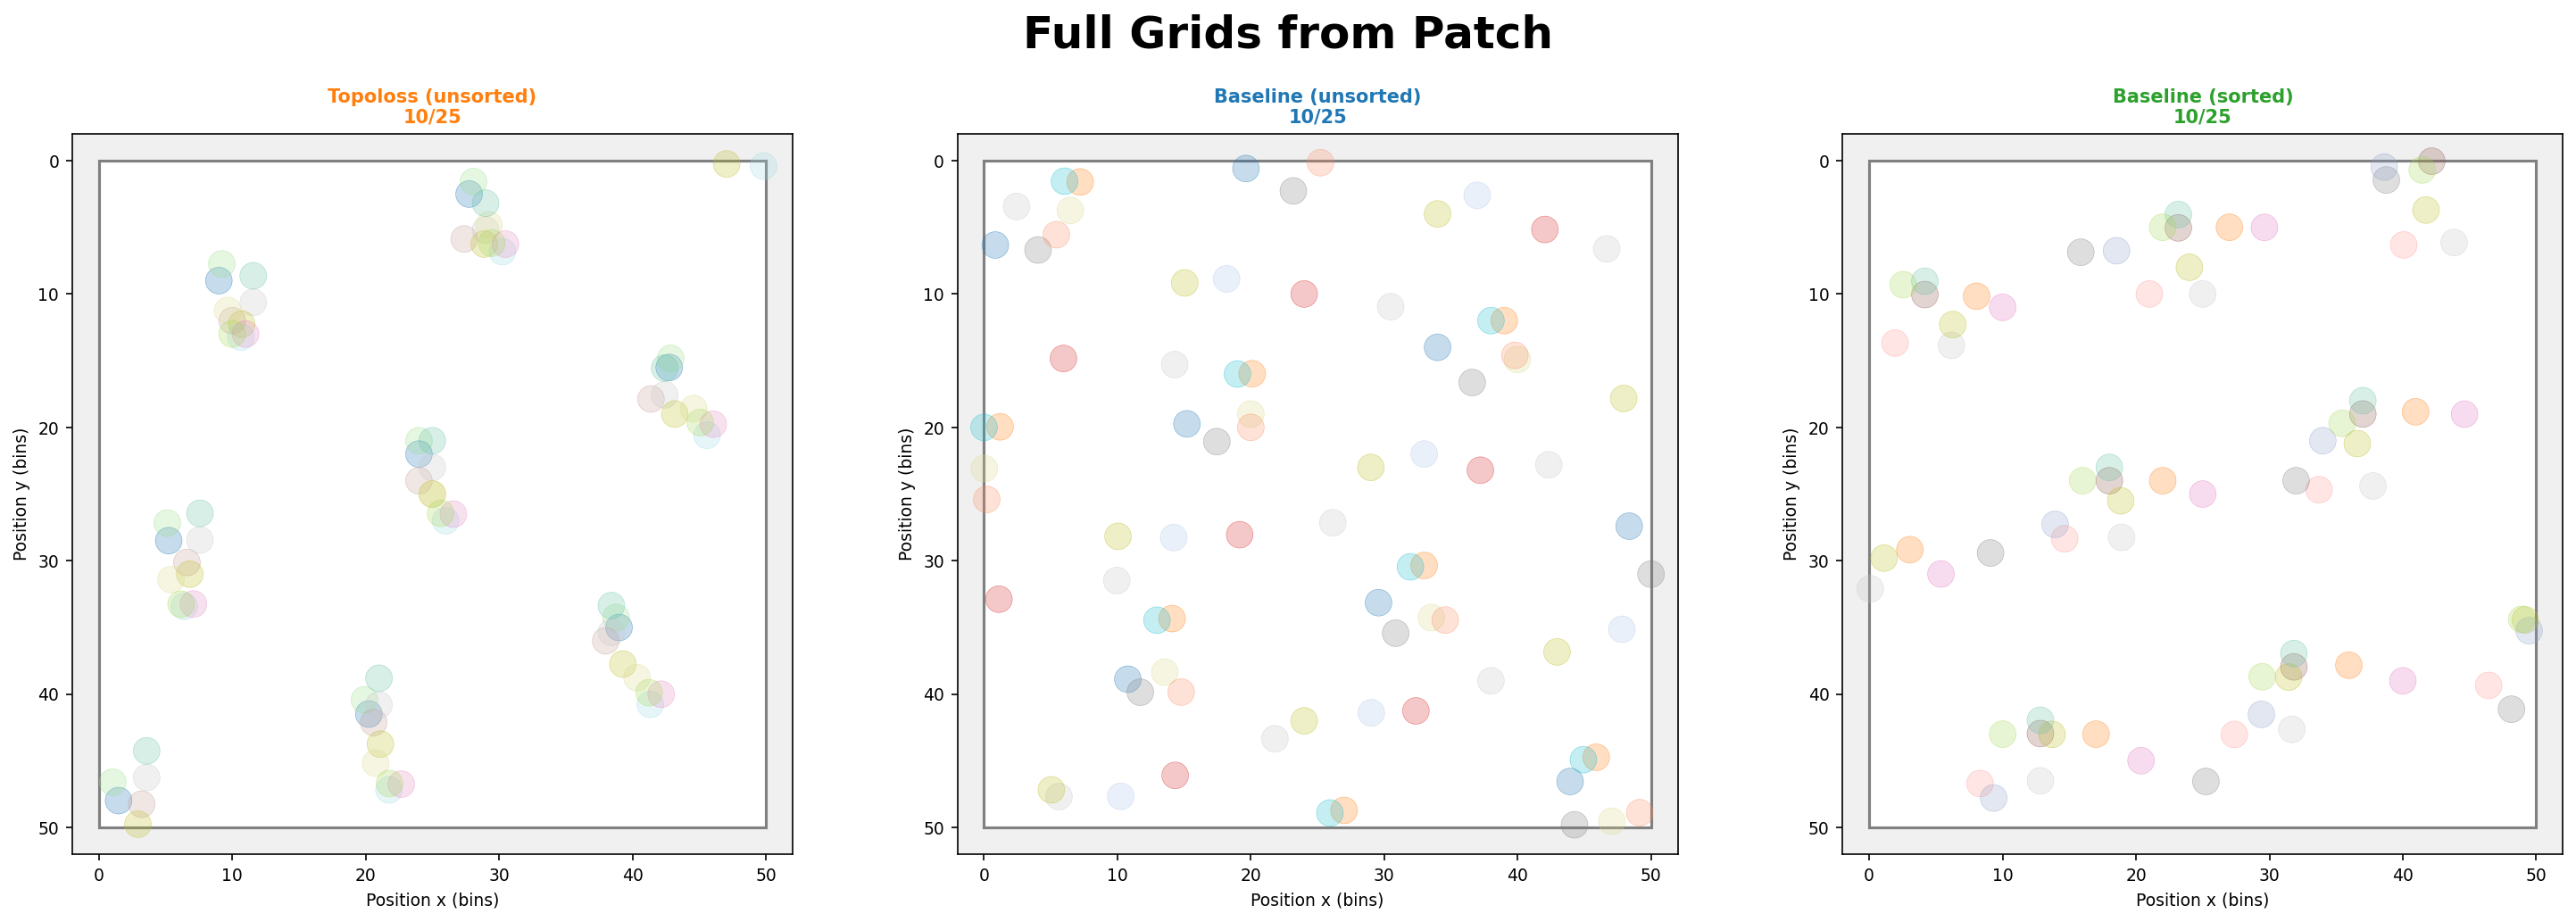


Topoloss (unsorted)
 Patch Pos  Neuron  Grid Score  Orientation (degrees)  Scale (pixels)  Phase dx  Phase dy
  (-2, -2)     726       1.222        40.9        19.8        -1        -3
  (-1, -2)     790       1.282        41.9        19.8        -1        -4
  (+0, -1)     855       1.278        40.6        18.4        -1        -1
  (+1, -2)     918       1.337        42.6        18.2         0        -2
  (+1, -1)     919       1.283        41.7        19.1         0         0
  (+1, +0)     920       1.226        41.9        20.6         0         0
  (+1, +2)     922       1.261        41.9        20.6         1         2
  (+2, -2)     982       1.349        42.6        18.2         0        -4
  (+2, +1)     985       1.306        40.9        20.6       -14       -12
  (+2, +2)     986       1.361        40.7        20.6       -15       -12

Orientation: mean=41.6 degrees, std=0.7 degrees
Scale: mean=19.6 pixels, std=1.0 pixels

Baseline (unsorted)
 Patch Pos  Neuron  Grid Scor

In [54]:
MIN_GRID_SCORE = 0.9
BLOB_RADIUS = 1
N_NEURONS = 10 # Overrides min grid score if nonzero

import cv2
import scipy.signal as sp_sig
from matplotlib import gridspec
from matplotlib.patches import Circle
from scipy.ndimage import maximum_filter

patch_size = 5
mid = patch_size // 2

def _compute_sac_full(rm):
    c = rm - rm.mean()
    sac = sp_sig.fftconvolve(c, c[::-1, ::-1], mode='full')
    return sac / (np.abs(sac).max() + 1e-10)

def _extract_grid_params(sac):
    """
    Returns orientation and scale
    """
    ny, nx = sac.shape
    cy, cx = ny // 2, nx // 2
    
    Y, X = np.ogrid[:ny, :nx]
    r = np.sqrt((X - cx)**2 + (Y - cy)**2)
    center_mask_r = min(cy, cx) * 0.18
    outer_mask_r = min(cy, cx) * 0.85
    
    sac_masked = sac.copy()
    sac_masked[r < center_mask_r] = 0
    sac_masked[r > outer_mask_r] = 0
    
    neighborhood = maximum_filter(sac_masked, size=7)
    peaks = (sac_masked == neighborhood) & (sac_masked > 0.15)
    peak_ys, peak_xs = np.where(peaks)
    
    if len(peak_ys) < 3:
        peaks = (sac_masked == neighborhood) & (sac_masked > 0.05)
        peak_ys, peak_xs = np.where(peaks)
    
    if len(peak_ys) < 3:
        return 0.0, 10.0
    
    dists = np.sqrt((peak_xs - cx)**2 + (peak_ys - cy)**2)
    order = np.argsort(dists)
    
    n_ring = min(6, len(order))
    ring_idx = order[:n_ring]
    ring_x = peak_xs[ring_idx] - cx
    ring_y = peak_ys[ring_idx] - cy
    ring_dists = dists[ring_idx]
    
    scale = np.median(ring_dists)
    
    angles = np.arctan2(ring_y, ring_x)
    angles = angles % (2 * np.pi)
    angles_60 = angles % (np.pi / 3)
    orientation = np.median(angles_60)
    
    return orientation, scale

def _extract_phase_offset(rm, center_rm):
    """
    Returns phase in x and y
    """
    c1 = center_rm - center_rm.mean()
    c2 = rm - rm.mean()
    xcorr = sp_sig.fftconvolve(c1, c2[::-1, ::-1], mode='same')
    res = rm.shape[0]
    pk = np.unravel_index(np.argmax(xcorr), xcorr.shape)
    dx = -(pk[1] - res // 2)
    dy = -(pk[0] - res // 2)
    return dx, dy

def _generate_hex_centers(orientation, scale, phase_dx, phase_dy, extent=55):
    """
    Generate full hexagonal grid given phase, scale, orientation
    """
    a1 = scale * np.array([np.cos(orientation), np.sin(orientation)])
    a2 = scale * np.array([np.cos(orientation + np.pi / 3),
                           np.sin(orientation + np.pi / 3)])
    
    n_max = int(np.ceil(extent / scale)) + 3
    centers = []
    cx, cy = extent / 2 + phase_dx, extent / 2 + phase_dy
    for i in range(-n_max, n_max + 1):
        for j in range(-n_max, n_max + 1):
            pt = np.array([cx, cy]) + i * a1 + j * a2
            if -scale < pt[0] < extent + scale and -scale < pt[1] < extent + scale:
                centers.append(pt)
    return centers

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

cmap_neurons = plt.cm.tab20(np.linspace(0, 1, 20))
extra_5 = plt.cm.Set2(np.linspace(0, 1, 8))[:5]
neuron_colors = np.vstack([cmap_neurons, extra_5])

env_size = 50

model_tables = []

for col, (model_label, patches, scores, act, color) in enumerate([
    ("Topoloss (unsorted)", topo_patches, topo_score60, topo_act, "C1"),
    ("Baseline (unsorted)", baseline_patches_unsorted, baseline_score60, baseline_act, "C0"),
    ("Baseline (sorted)", baseline_patches_sorted, baseline_score60_sorted, baseline_act_sorted, "C2"),
]):
    ax = axes[col]
    cy, cx = patches[0] # Chosen patch
    
    neurons = []
    rms = []
    patch_positions = []
    for di in range(patch_size):
        for dj in range(patch_size):
            ri = cy - mid + di
            ci = cx - mid + dj
            neurons.append(ri * n + ci)
            rm = cv2.GaussianBlur(act[ri * n + ci], (3, 3), sigmaX=1, sigmaY=1)
            rms.append(rm)
            patch_positions.append((di - mid, dj - mid))
    
    # Determines neurons to plot
    neuron_scores = np.array([scores[nidx] for nidx in neurons])
    if N_NEURONS > 0:
        top_k = np.argsort(neuron_scores)[::-1][:N_NEURONS]
        plot_set = set(top_k.tolist())
    else:
        plot_set = set(k for k in range(len(neurons)) if neuron_scores[k] >= MIN_GRID_SCORE)
    
    center_idx = mid * patch_size + mid
    center_rm = rms[center_idx]
    
    ax.set_facecolor('#f0f0f0')
    ax.set_xlim(-2, env_size + 2)
    ax.set_ylim(env_size + 2, -2)
    ax.set_aspect('equal')
    ax.add_patch(plt.Rectangle((0, 0), env_size, env_size,
                               facecolor='white', edgecolor='gray',
                               linewidth=1.5, zorder=0))
    
    # Overlay each neuron's "full/perfect" grid and collect stats
    table_rows = []
    for k in range(len(neurons)):
        if k not in plot_set:
            continue
        
        rm_k = rms[k]
        
        sac_k = _compute_sac_full(rm_k)
        orient_k, scale_k = _extract_grid_params(sac_k)
        
        if k == center_idx:
            pdx, pdy = 0, 0
        else:
            pdx, pdy = _extract_phase_offset(rm_k, center_rm)
        
        centers = _generate_hex_centers(orient_k, scale_k, pdx, pdy,
                                        extent=env_size)
        
        c_rgba = list(neuron_colors[k][:3]) + [0.25]
        for (gx, gy) in centers:
            if 0 <= gx <= env_size and 0 <= gy <= env_size:
                circle = Circle((gx, gy), BLOB_RADIUS,
                                facecolor=c_rgba,
                                edgecolor=list(neuron_colors[k][:3]) + [0.5],
                                linewidth=0.3, zorder=2)
                ax.add_patch(circle)
        
        di_rel, dj_rel = patch_positions[k]
        table_rows.append({
            'patch_pos': f"({di_rel:+d}, {dj_rel:+d})",
            'neuron_idx': neurons[k],
            'grid_score': neuron_scores[k],
            'orientation_deg': np.degrees(orient_k),
            'scale_px': scale_k,
            'phase_dx': pdx,
            'phase_dy': pdy,
        })
    
    model_tables.append((model_label, table_rows))
    
    ax.set_title(f"{model_label}\n"
                 f"{len(plot_set)}/25",
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Position x (bins)', fontsize=9)
    ax.set_ylabel('Position y (bins)', fontsize=9)

fig.suptitle(
    "Full Grids from Patch",
    fontsize=24, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Print stats
for model_label, rows in model_tables:
    print(f"\n{model_label}")
    print(f"{'Patch Pos':>10s}  {'Neuron':>6s}  {'Grid Score':>10s}  "
          f"{'Orientation (degrees)':>10s}  {'Scale (pixels)':>10s}  "
          f"{'Phase dx':>8s}  {'Phase dy':>8s}")
    for r in rows:
        print(f"{r['patch_pos']:>10s}  {r['neuron_idx']:>6d}  {r['grid_score']:>10.3f}  "
              f"{r['orientation_deg']:>10.1f}  {r['scale_px']:>10.1f}  "
              f"{r['phase_dx']:>8d}  {r['phase_dy']:>8d}")
    # Summary stats
    orients = [r['orientation_deg'] for r in rows]
    scales = [r['scale_px'] for r in rows]
    print(f"\nOrientation: mean={np.mean(orients):.1f} degrees, std={np.std(orients):.1f} degrees")
    print(f"Scale: mean={np.mean(scales):.1f} pixels, std={np.std(scales):.1f} pixels")

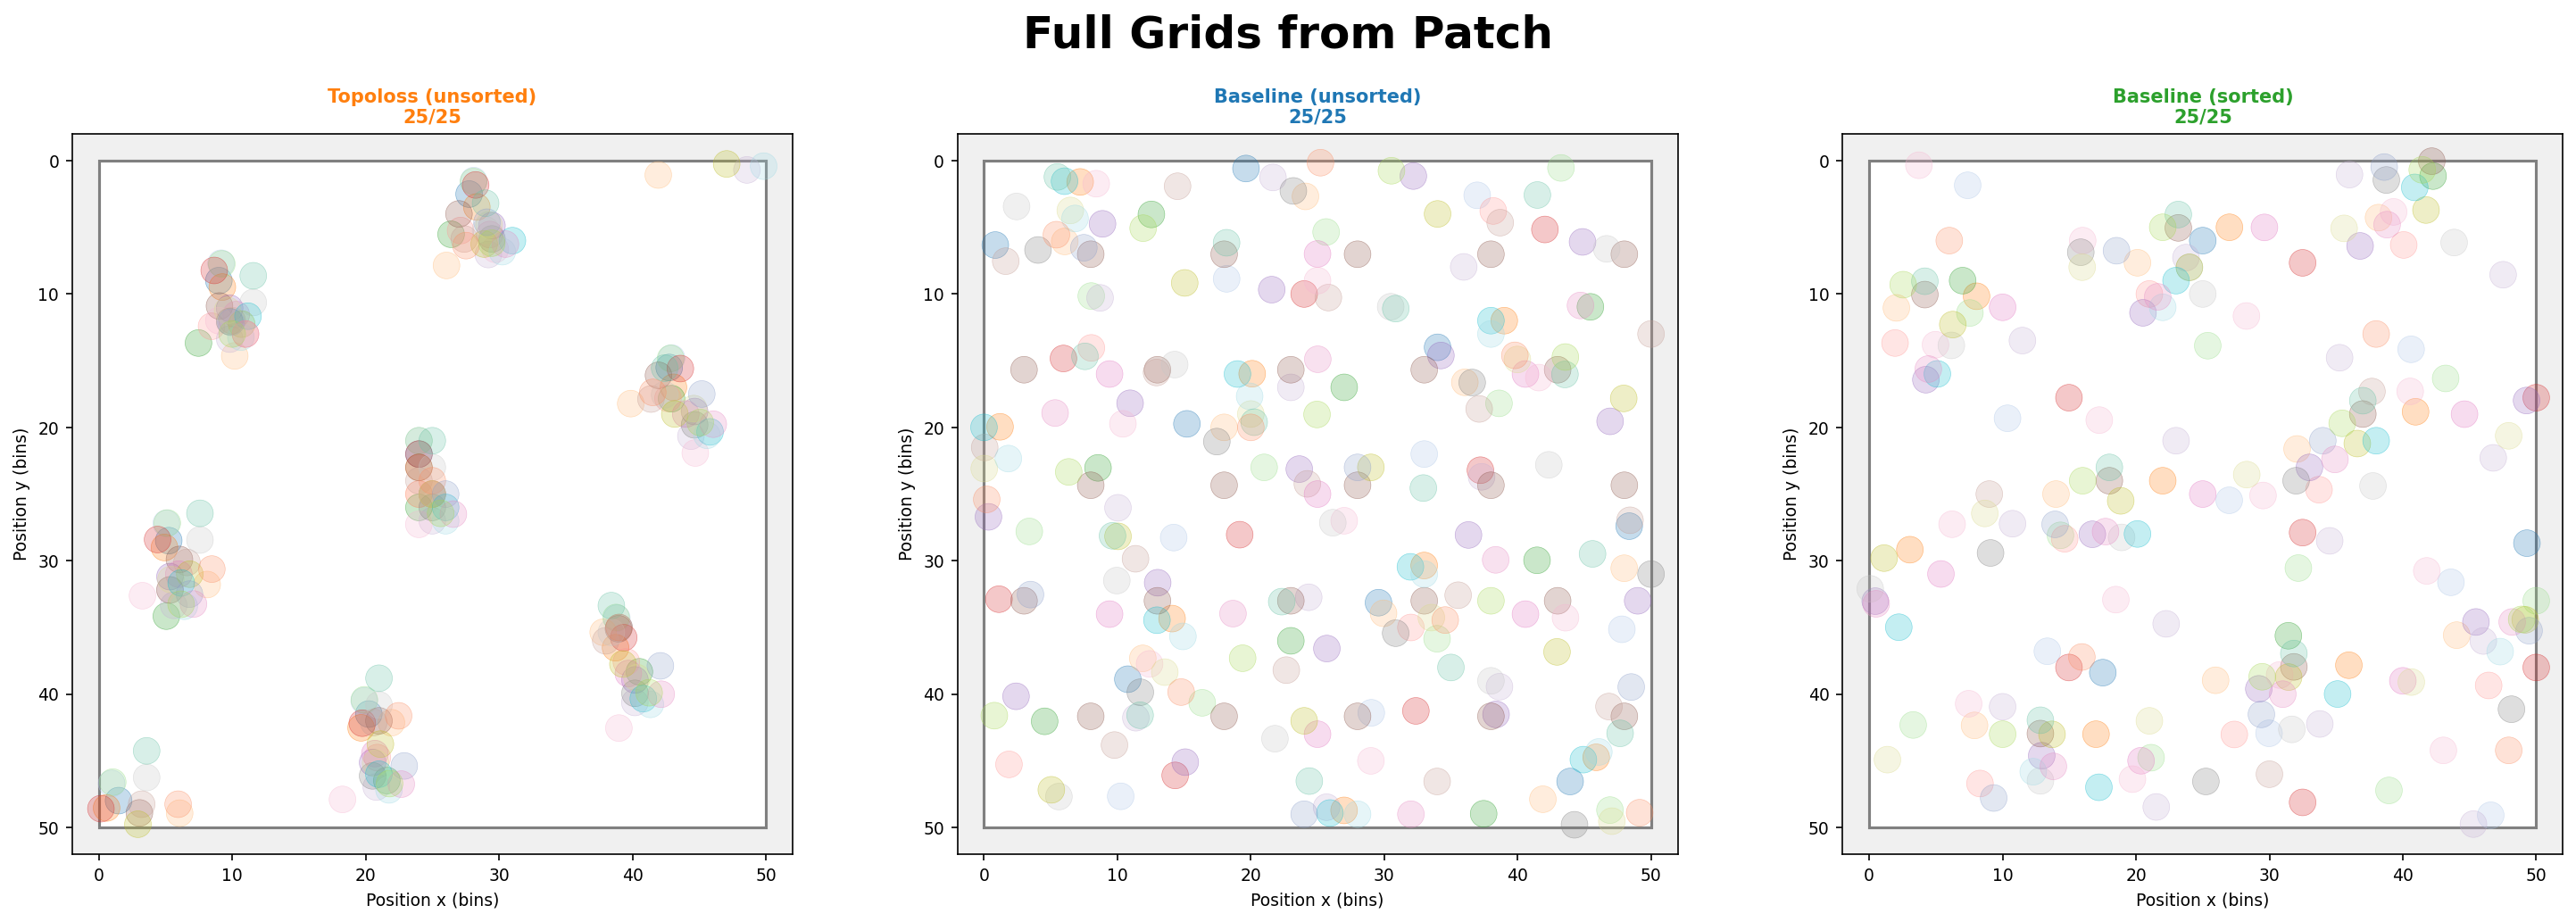


Topoloss (unsorted)
 Patch Pos  Neuron  Grid Score  Orientation (degrees)  Scale (pixels)  Phase dx  Phase dy
  (-2, -2)     726       1.222        40.9        19.8        -1        -3
  (-2, -1)     727       1.185        41.9        19.9        -1        -4
  (-2, +0)     728       0.871        42.5        20.0        -1        -2
  (-2, +1)     729       0.763        36.9        17.3        -1         0
  (-2, +2)     730       0.896        36.7        20.6        -1         1
  (-1, -2)     790       1.282        41.9        19.8        -1        -4
  (-1, -1)     791       0.928        41.9        20.6        -1        -3
  (-1, +0)     792       1.211        39.0        20.0        -1         0
  (-1, +1)     793       1.060        42.5        20.6         0         0
  (-1, +2)     794       1.117        41.9        20.4         0         2
  (+0, -2)     854       1.200        39.0        19.2        -1        -2
  (+0, -1)     855       1.278        40.6        18.4        -1

In [55]:
MIN_GRID_SCORE = 0.9
BLOB_RADIUS = 1
N_NEURONS = 25 # Overrides min grid score if nonzero

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

cmap_neurons = plt.cm.tab20(np.linspace(0, 1, 20))
extra_5 = plt.cm.Set2(np.linspace(0, 1, 8))[:5]
neuron_colors = np.vstack([cmap_neurons, extra_5])

env_size = 50

model_tables = []

for col, (model_label, patches, scores, act, color) in enumerate([
    ("Topoloss (unsorted)", topo_patches, topo_score60, topo_act, "C1"),
    ("Baseline (unsorted)", baseline_patches_unsorted, baseline_score60, baseline_act, "C0"),
    ("Baseline (sorted)", baseline_patches_sorted, baseline_score60_sorted, baseline_act_sorted, "C2"),
]):
    ax = axes[col]
    cy, cx = patches[0] # Chosen patch
    
    neurons = []
    rms = []
    patch_positions = []
    for di in range(patch_size):
        for dj in range(patch_size):
            ri = cy - mid + di
            ci = cx - mid + dj
            neurons.append(ri * n + ci)
            rm = cv2.GaussianBlur(act[ri * n + ci], (3, 3), sigmaX=1, sigmaY=1)
            rms.append(rm)
            patch_positions.append((di - mid, dj - mid))
    
    # Determines neurons to plot
    neuron_scores = np.array([scores[nidx] for nidx in neurons])
    if N_NEURONS > 0:
        top_k = np.argsort(neuron_scores)[::-1][:N_NEURONS]
        plot_set = set(top_k.tolist())
    else:
        plot_set = set(k for k in range(len(neurons)) if neuron_scores[k] >= MIN_GRID_SCORE)
    
    center_idx = mid * patch_size + mid
    center_rm = rms[center_idx]
    
    ax.set_facecolor('#f0f0f0')
    ax.set_xlim(-2, env_size + 2)
    ax.set_ylim(env_size + 2, -2)
    ax.set_aspect('equal')
    ax.add_patch(plt.Rectangle((0, 0), env_size, env_size,
                               facecolor='white', edgecolor='gray',
                               linewidth=1.5, zorder=0))
    
    # Overlay each neuron's "full/perfect" grid and collect stats
    table_rows = []
    for k in range(len(neurons)):
        if k not in plot_set:
            continue
        
        rm_k = rms[k]
        
        sac_k = _compute_sac_full(rm_k)
        orient_k, scale_k = _extract_grid_params(sac_k)
        
        if k == center_idx:
            pdx, pdy = 0, 0
        else:
            pdx, pdy = _extract_phase_offset(rm_k, center_rm)
        
        centers = _generate_hex_centers(orient_k, scale_k, pdx, pdy,
                                        extent=env_size)
        
        c_rgba = list(neuron_colors[k][:3]) + [0.25]
        for (gx, gy) in centers:
            if 0 <= gx <= env_size and 0 <= gy <= env_size:
                circle = Circle((gx, gy), BLOB_RADIUS,
                                facecolor=c_rgba,
                                edgecolor=list(neuron_colors[k][:3]) + [0.5],
                                linewidth=0.3, zorder=2)
                ax.add_patch(circle)
        
        di_rel, dj_rel = patch_positions[k]
        table_rows.append({
            'patch_pos': f"({di_rel:+d}, {dj_rel:+d})",
            'neuron_idx': neurons[k],
            'grid_score': neuron_scores[k],
            'orientation_deg': np.degrees(orient_k),
            'scale_px': scale_k,
            'phase_dx': pdx,
            'phase_dy': pdy,
        })
    
    model_tables.append((model_label, table_rows))
    
    ax.set_title(f"{model_label}\n"
                 f"{len(plot_set)}/25",
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Position x (bins)', fontsize=9)
    ax.set_ylabel('Position y (bins)', fontsize=9)

fig.suptitle(
    "Full Grids from Patch",
    fontsize=24, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Print stats
for model_label, rows in model_tables:
    print(f"\n{model_label}")
    print(f"{'Patch Pos':>10s}  {'Neuron':>6s}  {'Grid Score':>10s}  "
          f"{'Orientation (degrees)':>10s}  {'Scale (pixels)':>10s}  "
          f"{'Phase dx':>8s}  {'Phase dy':>8s}")
    for r in rows:
        print(f"{r['patch_pos']:>10s}  {r['neuron_idx']:>6d}  {r['grid_score']:>10.3f}  "
              f"{r['orientation_deg']:>10.1f}  {r['scale_px']:>10.1f}  "
              f"{r['phase_dx']:>8d}  {r['phase_dy']:>8d}")
    # Summary stats
    orients = [r['orientation_deg'] for r in rows]
    scales = [r['scale_px'] for r in rows]
    print(f"\nOrientation: mean={np.mean(orients):.1f} degrees, std={np.std(orients):.1f} degrees")
    print(f"Scale: mean={np.mean(scales):.1f} pixels, std={np.std(scales):.1f} pixels")